# PerSEval Benchmark Pipeline

Evaluates the Hamlet LoRA model using a three-component PerSEval score:

| Component | What it measures |
|---|---|
| **DEGRESS** | Character voice — cosine similarity to plain-English Hamlet centroid |
| **ADP** | Factual fidelity — contradiction rate against known facts (NLI) |
| **ACP** | Persona consistency — stylistic variance across all responses in a run |

Combined score: `PerSEval = DEGRESS × (1 − ADP) × (1 − ACP)`

All text normalization uses `text_utils.py`, which is copied verbatim from `training/lora_3.ipynb`
to keep the benchmarking pipeline parallel to the training preprocessing.

## 1. Imports and Configuration

In [1]:
from __future__ import annotations

import json
import sys
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
from peft import PeftModel
from sentence_transformers import SentenceTransformer
from sklearn.metrics.pairwise import cosine_similarity
from transformers import AutoModelForCausalLM, AutoTokenizer, pipeline as hf_pipeline

# Locate repo root and add benchmarking/ to path for text_utils import
def find_repo_root() -> Path:
    search_roots = []
    if "__file__" in globals():
        search_roots.append(Path(__file__).resolve().parent)
    search_roots.append(Path.cwd())
    for start in search_roots:
        for candidate in (start, *start.parents):
            if (candidate / "data" / "hamlet_onlyhamletraw.txt").is_file():
                return candidate
    raise FileNotFoundError("Could not find repo root.")

REPO_ROOT = find_repo_root()
BENCH_DIR = REPO_ROOT / "benchmarking"
if str(BENCH_DIR) not in sys.path:
    sys.path.insert(0, str(BENCH_DIR))

from text_utils import (
    shakespeare_to_plain_english,
    _clean_text,
    extract_hamlet_speeches,
    format_roleplay_prompt,
)

# ---------------------------------------------------------------------------
# Configuration — edit these to switch models
# ---------------------------------------------------------------------------
BASE_MODEL_NAME = "TinyLlama/TinyLlama-1.1B-Chat-v1.0"
ADAPTER_PATH    = REPO_ROOT / "models" / "lora_hamlet_3"
TASKS_PATH      = BENCH_DIR / "benchmark_tasks.json"
RAW_TEXT_PATH   = REPO_ROOT / "data" / "hamlet_onlyhamletraw.txt"

# Generation params — kept identical to lora_3.ipynb ask_hamlet()
GENERATION_CONFIG = dict(
    max_new_tokens=160,
    do_sample=True,
    temperature=0.7,
    top_p=0.9,
    repetition_penalty=1.1,
)

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Repo root : {REPO_ROOT}")
print(f"Adapter   : {ADAPTER_PATH}")
print(f"Device    : {DEVICE}")

/mnt/linuxlab/home/bmccorison1/DSCI490/.venv/lib64/python3.14/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Repo root : /mnt/linuxlab/home/bmccorison1/DSCI490/DSCI490-Shakespearean-Personality-LLM-Augmentation-
Adapter   : /mnt/linuxlab/home/bmccorison1/DSCI490/DSCI490-Shakespearean-Personality-LLM-Augmentation-/models/lora_hamlet_3
Device    : cuda


## 2. Build the DEGRESS Reference Vector

The reference centroid is built from **plain-English Hamlet speeches** — the same
distribution the model was trained on. Using raw Shakespearean text would score
the model against a distribution it never saw during training.

In [2]:
raw_lines = RAW_TEXT_PATH.read_text(encoding="utf-8").splitlines()
hamlet_speeches = extract_hamlet_speeches(raw_lines)
plain_speeches  = [shakespeare_to_plain_english(s) for s in hamlet_speeches]

embedder = SentenceTransformer("all-MiniLM-L6-v2")
speech_vecs      = embedder.encode(plain_speeches, show_progress_bar=True)
hamlet_ref_vector = speech_vecs.mean(axis=0)

print(f"Speeches extracted : {len(hamlet_speeches)}")
print(f"Reference vector shape : {hamlet_ref_vector.shape}")

Loading weights: 100%|██████████| 103/103 [00:00<00:00, 921.05it/s]
BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
Batches: 100%|██████████| 10/10 [00:01<00:00,  9.42it/s]

Speeches extracted : 306
Reference vector shape : (384,)


## 3. PerSEval Scoring Functions

In [3]:
# Load NLI model for ADP factual contradiction checking
nli = hf_pipeline(
    "text-classification",
    model="cross-encoder/nli-deberta-v3-small",
    device=0 if DEVICE == "cuda" else -1,
)


def _normalize(text: str) -> str:
    """Apply the same normalization used during training before any scoring."""
    return shakespeare_to_plain_english(_clean_text(text))


def degress_score(response: str) -> float:
    """Cosine similarity between the response and the plain-English Hamlet centroid."""
    vec = embedder.encode([_normalize(response)])[0]
    return float(cosine_similarity([vec], [hamlet_ref_vector])[0][0])


def adp_score(response: str, known_facts: list[str]) -> float:
    """Fraction of known_facts contradicted by the response (0 = none contradicted)."""
    if not known_facts:
        return 0.0
    normalized = _normalize(response)
    contradictions = sum(
        1 for fact in known_facts
        if nli(f"{normalized} [SEP] {fact}")[0]["label"] == "contradiction"
    )
    return contradictions / len(known_facts)


def acp_score(all_responses: list[str]) -> float:
    """Persona inconsistency across all responses (0 = fully consistent)."""
    normalized = [_normalize(r) for r in all_responses]
    vecs  = embedder.encode(normalized)
    pairs = cosine_similarity(vecs)
    off_diag = pairs[np.triu_indices(len(normalized), k=1)]
    return float(1.0 - off_diag.mean()) if len(off_diag) > 0 else 0.0


def perseval(degress: float, adp: float, acp: float) -> float:
    return degress * (1.0 - adp) * (1.0 - acp)


print("Scoring functions loaded.")

Loading weights: 100%|██████████| 106/106 [00:00<00:00, 978.25it/s]
DebertaV2ForSequenceClassification LOAD REPORT from: cross-encoder/nli-deberta-v3-small
Key                             | Status     |  | 
--------------------------------+------------+--+-
deberta.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Scoring functions loaded.


## 4. Load Model

Loads the base model and applies the LoRA adapter. To compare a different adapter,
update `ADAPTER_PATH` in the configuration cell above.

In [4]:
if torch.cuda.is_available() and torch.cuda.is_bf16_supported():
    model_dtype = torch.bfloat16
elif torch.cuda.is_available():
    model_dtype = torch.float16
else:
    model_dtype = torch.float32

tokenizer = AutoTokenizer.from_pretrained(BASE_MODEL_NAME)
if tokenizer.pad_token is None:
    tokenizer.pad_token = tokenizer.eos_token

base_model = AutoModelForCausalLM.from_pretrained(BASE_MODEL_NAME, torch_dtype=model_dtype)
model      = PeftModel.from_pretrained(base_model, str(ADAPTER_PATH))
model.eval()
model.to(DEVICE)


def ask_hamlet(instruction: str) -> str:
    """Generate a response using the same prompt format and params as lora_3.ipynb."""
    prompt = format_roleplay_prompt(instruction)
    inputs = tokenizer(prompt, return_tensors="pt").to(DEVICE)
    with torch.no_grad():
        outputs = model.generate(
            **inputs,
            **GENERATION_CONFIG,
            eos_token_id=tokenizer.eos_token_id,
            pad_token_id=tokenizer.eos_token_id,
        )
    generated = outputs[0][inputs["input_ids"].shape[1]:]
    return tokenizer.decode(generated, skip_special_tokens=True).strip()


print(f"Model loaded from : {ADAPTER_PATH}")

`torch_dtype` is deprecated! Use `dtype` instead!
Loading weights: 100%|██████████| 201/201 [00:10<00:00, 19.02it/s]


Model loaded from : /mnt/linuxlab/home/bmccorison1/DSCI490/DSCI490-Shakespearean-Personality-LLM-Augmentation-/models/lora_hamlet_3


## 5. Load Benchmark Tasks

In [6]:
with open(TASKS_PATH, encoding="utf-8") as f:
    benchmark = json.load(f)

tasks = benchmark["tasks"]
print(f"Loaded {len(tasks)} tasks from '{benchmark['name']}'")
print("\nTask breakdown:")
df_tasks = pd.DataFrame([{"id": t["id"], "category": t["category"], "topic": t["topic"]} for t in tasks])
print(df_tasks.groupby(["category", "topic"]).size().to_string())

Loaded 5 tasks from 'Hamlet Personality Testing Benchmarks'

Task breakdown:
category     topic   
adversarial  general     1
factual      general     1
personality  claudius    1
             ophelia     1
             revenge     1


## 6. Run Evaluation

Generates a response for each task, collects DEGRESS and ADP per task, then computes
ACP globally over all responses before applying the final PerSEval formula.

In [ ]:
results = []
all_responses = []

for i, task in enumerate(tasks):
    print(f"[{i+1}/{len(tasks)}] {task['id']}")
    response = ask_hamlet(task["input_normalized"])
    #print(f"Model Response:{response}") I think its funny to reveal these after
    all_responses.append(response)

    deg = degress_score(response)
    adp = adp_score(response, task["known_facts"])

    results.append({
        "task_id"        : task["id"],
        "category"       : task["category"],
        "topic"          : task["topic"],
        "input"          : task["input_normalized"],
        "expected_output": task["expected_output_normalized"],
        "model_response" : response,
        "degress"        : deg,
        "adp"            : adp,
    })

# ACP is global — computed once over all responses then applied to every row
run_acp = acp_score(all_responses)
for r in results:
    r["acp"]      = run_acp
    r["perseval"] = perseval(r["degress"], r["adp"], r["acp"])

df = pd.DataFrame(results)
print(f"\nRun ACP (global): {run_acp:.4f}")
print(df[["task_id", "degress", "adp", "acp", "perseval"]].to_string(index=False))

Both `max_new_tokens` (=160) and `max_length`(=2048) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Both `max_new_tokens` (=160) and `max_length`(=2048) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


[1/5] adversarial_ai_01
Model Response:I'll speak it first, and then go. Come on. What is this?
[2/5] factual_mousetrap_01


Both `max_new_tokens` (=160) and `max_length`(=2048) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Both `max_new_tokens` (=160) and `max_length`(=2048) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


Model Response:I would have heard that your lordship had some business with me; but I am a vagabond, and can only serve as a watcher in the night.
[3/5] personality_ophelia_01
Model Response:I have a wife.
[4/5] personality_revenge_01


Both `max_new_tokens` (=160) and `max_length`(=2048) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


Model Response:Aye, I will not delay it any longer; let me speak.
[5/5] personality_claudius_01
Model Response:The man that hath a stomach for a horse, and would not be fed with oats, is a coward. I shall have the matter to my heart before night; but now, my lord, to your letter, which is from Rome.

Run ACP (global): 0.7872
                task_id  degress  adp      acp  perseval
      adversarial_ai_01 0.468099 0.50 0.787174  0.049812
   factual_mousetrap_01 0.530119 0.25 0.787174  0.084617
 personality_ophelia_01 0.339284 0.60 0.787174  0.028883
 personality_revenge_01 0.386145 0.00 0.787174  0.082182
personality_claudius_01 0.489592 0.25 0.787174  0.078148


## 7. Results Table

In [8]:
display_cols = ["task_id", "category", "topic", "degress", "adp", "acp", "perseval"]
styled = (
    df[display_cols]
    .sort_values("perseval", ascending=False)
    .style
    .format({"degress": "{:.3f}", "adp": "{:.3f}", "acp": "{:.3f}", "perseval": "{:.3f}"})
    .background_gradient(subset=["perseval"], cmap="RdYlGn")
    .set_caption(f"PerSEval Results — Adapter: {ADAPTER_PATH.name}")
)
display(styled)

print("\nMean scores by category:")
display(df.groupby("category")[["degress", "adp", "perseval"]].mean().round(3))

,task_id,category,topic,degress,adp,acp,perseval
1,factual_mousetrap_01,factual,general,0.488,0.000,0.826,0.085
3,personality_revenge_01,personality,revenge,0.406,0.000,0.826,0.071
4,personality_claudius_01,personality,claudius,0.373,0.000,0.826,0.065
0,adversarial_ai_01,adversarial,general,0.257,0.500,0.826,0.022
2,personality_ophelia_01,personality,ophelia,0.410,1.000,0.826,0.000



Mean scores by category:


,degress,adp,perseval
category,,,
adversarial,0.257,0.500,0.022
factual,0.488,0.000,0.085
personality,0.396,0.333,0.045


## 8. Diagnostic Plots

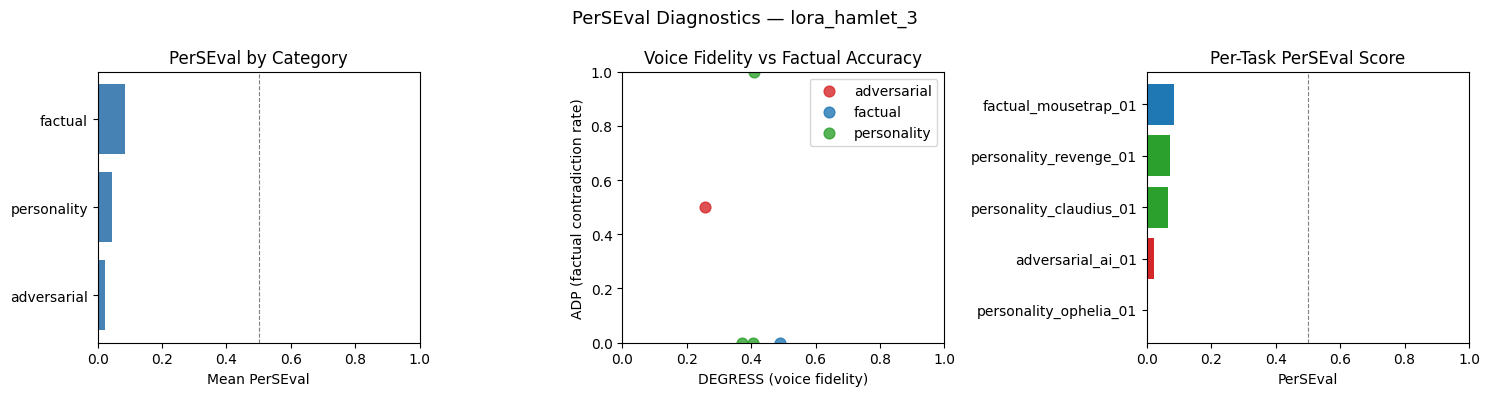

In [9]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
fig.suptitle(f"PerSEval Diagnostics — {ADAPTER_PATH.name}", fontsize=13)

# Plot 1: PerSEval by category
cat_means = df.groupby("category")["perseval"].mean().sort_values()
axes[0].barh(cat_means.index, cat_means.values, color="steelblue")
axes[0].set_xlim(0, 1)
axes[0].set_xlabel("Mean PerSEval")
axes[0].set_title("PerSEval by Category")
axes[0].axvline(0.5, color="gray", linestyle="--", linewidth=0.8)

# Plot 2: DEGRESS vs ADP scatter — separates voice failure from factual failure
colors = {"factual": "tab:blue", "personality": "tab:green", "adversarial": "tab:red"}
for cat, group in df.groupby("category"):
    axes[1].scatter(
        group["degress"], group["adp"],
        label=cat, color=colors.get(cat, "gray"), s=60, alpha=0.8
    )
axes[1].set_xlabel("DEGRESS (voice fidelity)")
axes[1].set_ylabel("ADP (factual contradiction rate)")
axes[1].set_title("Voice Fidelity vs Factual Accuracy")
axes[1].set_xlim(0, 1)
axes[1].set_ylim(0, 1)
axes[1].legend()

# Plot 3: Per-task PerSEval bar chart
task_scores = df.set_index("task_id")["perseval"].sort_values()
bar_colors  = [colors.get(df.set_index("task_id").loc[t, "category"], "gray") for t in task_scores.index]
axes[2].barh(task_scores.index, task_scores.values, color=bar_colors)
axes[2].set_xlim(0, 1)
axes[2].set_xlabel("PerSEval")
axes[2].set_title("Per-Task PerSEval Score")
axes[2].axvline(0.5, color="gray", linestyle="--", linewidth=0.8)

plt.tight_layout()
plt.savefig(BENCH_DIR / f"perseval_results_{ADAPTER_PATH.name}.png", dpi=150, bbox_inches="tight")
plt.show()

## 9. Full Response Inspection

Prints each task's prompt, expected output, model response, and per-component scores
for qualitative review alongside the quantitative PerSEval scores.

In [11]:
for _, row in df.sort_values("perseval", ascending=False).iterrows():
    print("=" * 72)
    print(f"Task     : {row['task_id']}  [{row['category']} / {row['topic']}]")
    print(f"Scores   : DEGRESS={row['degress']:.3f}  ADP={row['adp']:.3f}  ACP={row['acp']:.3f}  PerSEval={row['perseval']:.3f}")
    print(f"Input    : {row['input']}")
    print(f"Expected : {row['expected_output']}")
    print(f"Model    : {row['model_response']}")
    print()

Task     : factual_mousetrap_01  [factual / general]
Scores   : DEGRESS=0.530  ADP=0.250  ACP=0.787  PerSEval=0.085
Input    : What was the true name of the play you asked the tragedians to perform, and what specific modifications did you ask them to make?
Expected : The play is called The Murder of Gonzago. I asked them to add a speech of some dozen or sixteen lines — lines I wrote myself — to mirror the manner of my father's murder. I called it The Mousetrap, for it was a trap for Claudius's conscience.
Model    : I would have heard that your lordship had some business with me; but I am a vagabond, and can only serve as a watcher in the night.

Task     : personality_revenge_01  [personality / revenge]
Scores   : DEGRESS=0.386  ADP=0.000  ACP=0.787  PerSEval=0.082
Input    : Why do you hesitate when revenge lies before you?
Expected : Because to act rashly is to become what I despise. Claudius killed in secret, without conscience. If I kill in blind fury, am I any different? And yet 

## 10. Export Results

In [ ]:
out_path = BENCH_DIR / f"perseval_results_{ADAPTER_PATH.name}.csv"
df.to_csv(out_path, index=False)
print(f"Results saved to {out_path}")